:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`ndimensional_foureir_basis.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(fourier-basis-doc)=
# Fourier Basis

The Fourier basis uses a slightly different API from other bases in NeMoS. This page covers everything you need to use it.

## One-Dimensional Fourier Basis

A one-dimensional Fourier basis is a complex basis whose elements are

$$
a_n(x) \;=\; \cos\!\Bigl(2\pi \frac{n}{P}\,x\Bigr) \;+\; i\,\sin\!\Bigl(2\pi \frac{n}{P}\,x\Bigr),
$$

where $P>0$ is the period, $x$ is the input variable, and $n\in\mathbb{N}$ is the frequency index.

### Fourier Basis in NeMoS

In NeMoS, you can define a `FourierEval` basis object with the following syntax:

In [2]:
from nemos.basis import FourierEval
import numpy as np
import matplotlib.pyplot as plt

# 5 frequencies, from 0 to 4, no masking
# (the default behavior is masking-out frequency 0, see below)
fourier_1d = FourierEval(frequencies=5, frequency_mask=None)

x = np.linspace(0, 1, 400)
X = fourier_1d.compute_features(x)

print("frequencies:", fourier_1d.masked_frequencies[0].tolist())
print("design matrix shape:", X.shape)  # (n_samples, n_features)

frequencies: [0.0, 1.0, 2.0, 3.0, 4.0]
design matrix shape: (400, 9)


The `compute_features` method of the basis returns a **real** design matrix that splits real and imaginary parts into separate columns, first the cosine columns then the sine.

:::{admonition} How did we get this number of columns in the design matrix?
:class: info

Let the selected frequencies be the sorted set $\mathcal F=\{n_1<\cdots<n_K\}$.

Each frequency contributes a cosine and a sine, so with $K$ frequencies you’d expect $2K$ columns. This is the case when the 0 frequency - DC term - is not included. If the DC term is included, we have that the corresponding sine column is null, since $\sin(0)=0$. For this reason, the column is omitted — giving $2K-1$. In our example $K=5$ and the DC term is included, therefore we obtain $2*5-1=9$ columns. Summarizing,

- $n_1=0$ (with DC):

  $$
  \bigl[\;1,\,\cos(2\pi \frac{n_2}{P}x),\,\ldots,\,\cos(2\pi \frac{n_K}{P}x),\ \ \sin(2\pi \frac{n_2}{P}x),\,\ldots,\,\sin(2\pi \frac{n_K}{P}x)\;\bigr],
  $$

  total columns $=2K-1$.

- $n_1>0$ (without DC):

  $$
  \bigl[\;\cos(2\pi \frac{n_1}{P}x),\,\ldots,\,\cos(2\pi \frac{n_K}{P}x),\ \ \sin(2\pi \frac{n_1}{P}x),\,\ldots,\,\sin(2\pi \frac{n_K}{P}x)\;\bigr],
  $$

  total columns $=2K$.
:::

5 frequencies including the DC term:
frequencies: [0. 1. 2. 3. 4.]
output features: 5 * 2 - 1 =  9


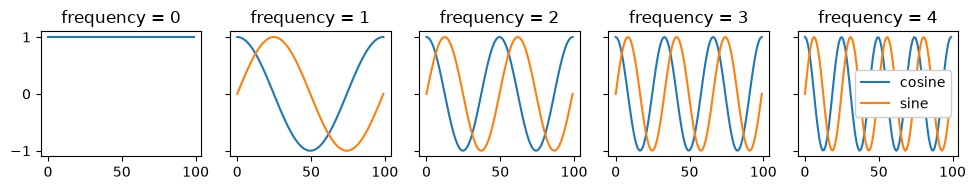

In [3]:
# NOTE: here and below, '5' = number of frequencies (K in the math)
print("5 frequencies including the DC term:")
print("frequencies:", fourier_1d.frequencies[0])
print("output features: 5 * 2 - 1 = ",  fourier_1d.n_basis_funcs)

# `evaluate_on_grid` calls `compute_features` on a grid of point
_, X = fourier_1d.evaluate_on_grid(100)
f, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
for freq in fourier_1d.frequencies[0]:
    axs[int(freq)].set_title(f"frequency = {int(freq)}")
    axs[int(freq)].plot(X[:, int(freq)], label="cosine")
    if freq != 0:
        # to get the corresponding sin column
        # add the num of frequencies (5), minus dc term (1)
        idx_sin = int(freq) + 5 - 1
        axs[int(freq)].plot(X[:, idx_sin], label="sine")
plt.legend(framealpha=1)
plt.tight_layout()
plt.show()


**Without DC (1..5): same pair**


5 frequencies without the DC term:
frequencies: [1. 2. 3. 4. 5.]
output features: 5 * 2 =  10


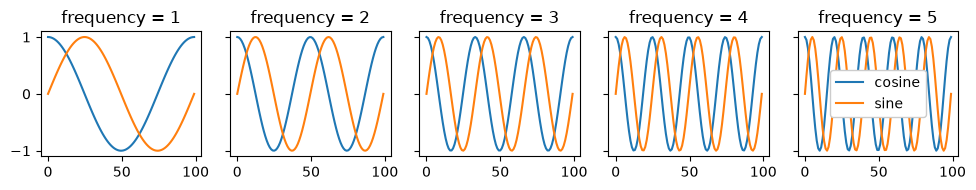

In [4]:
# drop the DC term (5 frequencies)
fourier_1d = FourierEval(frequencies=(1, 6))
print("\n5 frequencies without the DC term:")
print("frequencies:", fourier_1d.frequencies[0])
print("output features: 5 * 2 = ",  fourier_1d.n_basis_funcs)

f, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)

# `evaluate_on_grid` calls `compute_features` on a grid of point
_, X = fourier_1d.evaluate_on_grid(100)
for freq in fourier_1d.frequencies[0]:
    idx_freq = int(freq) - 1
    axs[idx_freq].set_title(f"frequency = {int(freq)}")
    axs[idx_freq].plot(X[:, idx_freq], label="cosine")
    # to get the corresponding sin column
    # add the num of frequencies (5), no dc term to subtract
    idx_sin = idx_freq + 5
    axs[idx_freq].plot(X[:, idx_sin], label="sine")
plt.legend(framealpha=1)
plt.tight_layout()
plt.show()


### Selecting frequencies

You can provide `frequencies` as:

- An integer $n$, that will result in frequencies $0, \ldots, n-1$.
- A range $(n, m)$, that will result in frequencies $n, \ldots, m-1$.
- An array of integers.
- A list of length `ndim` of any of the above.

:::{warning}

**Important distinction between lists and arrays:**

- An **array** (`np.array([4, 5])`): Specifies the exact frequencies `[4, 5]` (sorted) for **all dimensions**
- A **list** (`[4, 5]`): Specifies different frequency specifications **per dimension** - 4 frequencies `[0,1,2,3]` for dimension 1, and 5 frequencies `[0,1,2,3,4]` for dimension 2

This difference allows flexible specification: use arrays when you want the same custom frequencies across all dimensions, use lists when you want different frequency specifications per dimension.
:::

In [5]:
fourier_1d = FourierEval(frequencies=5)
print("- frequencies=5: ", fourier_1d.frequencies)

fourier_1d = FourierEval(frequencies=(5, 10))
print("- frequencies=(5, 10): ", fourier_1d.frequencies)

fourier_1d = FourierEval(frequencies=np.array([1, 3, 5]))
print("- frequencies=np.array([1, 3, 5]): ", fourier_1d.frequencies)

- frequencies=5:  [Array([0., 1., 2., 3., 4.], dtype=float32)]
- frequencies=(5, 10):  [Array([5., 6., 7., 8., 9.], dtype=float32)]


- frequencies=np.array([1, 3, 5]):  [Array([1., 3., 5.], dtype=float32)]


By default, NeMoS **masks out** the intercept (the DC term at frequency `0`). This is because NeMoS bases are most often used to build design matrices for GLMs, and NeMoS GLMs already include an intercept; adding another would be redundant.

In [6]:
# default masking
fourier_1d = FourierEval(frequencies=5)

# masked frequencies are 1..4
print("masked frequencies: ", fourier_1d.masked_frequencies[0])

# number of output features: (4 frequencies) * 2 = 8  (cos & sin)
fourier_1d.compute_features(np.linspace(0, 1, 10)).shape

masked frequencies:  [1. 2. 3. 4.]


(10, 8)

You can override this behavior by setting `frequency_mask` to `None` or `"all"` to keep the DC term.

In [7]:
# keep all frequencies, including 0 (DC)
fourier_1d = FourierEval(frequencies=5, frequency_mask=None)

# masked frequencies are 0..4
print("masked frequencies: ", fourier_1d.masked_frequencies[0])

# number of output features: (5 frequencies)*2 - 1 = 9
# (DC contributes only a cosine term; no sine at 0)
fourier_1d.compute_features(np.linspace(0, 1, 10)).shape

masked frequencies:  [0. 1. 2. 3. 4.]


(10, 9)

(fourier-period)=
### Setting the Period of the Basis

When evaluating the basis at some values $\boldsymbol{x} = \{x_1,...,x_t\}$, NeMoS assumes that the period of the basis is $P = \max(\boldsymbol{x}) - \min(\boldsymbol{x})$. The basis element with frequency equal to $n$ will therefore oscillate $n$ times over the range of values covered by $\boldsymbol{x}$.


:::{dropdown} More on the Fourier Mapping
:color: info
:icon: info


More precisely, let $\boldsymbol{x}=(x_1,\ldots,x_T)$. For an integer $n\ge 0$, the $n$-th Fourier basis element maps each $x_j$ to

$$
a_n(x_j)
= \cos\!\left(2\pi n\,\frac{x_j-\min(\boldsymbol{x})}{\max(\boldsymbol{x})-\min(\boldsymbol{x})}\right)
\;+\; i\,\sin\!\left(2\pi n\,\frac{x_j-\min(\boldsymbol{x})}{\max(\boldsymbol{x})-\min(\boldsymbol{x})}\right).
$$

for $j=1,\ldots,T$.

* The fundamental period over $x$ is $P=\max(\boldsymbol{x})-\min(\boldsymbol{x})$: the $n$-th basis element completes $n$ full cycles as $x$ runs from $\min(\boldsymbol{x})$ to $\max(\boldsymbol{x})$.
* The phase is zero at $\min(\boldsymbol{x})$: $a_n(\min(\boldsymbol{x}))=1+0i$.

:::

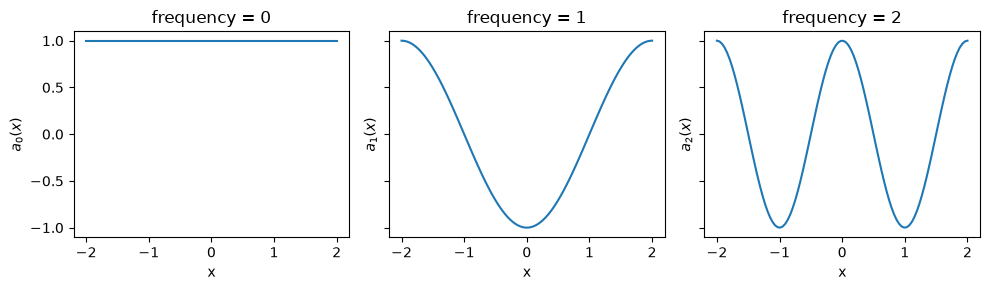

In [8]:
fourier_1d = FourierEval(frequencies=5, frequency_mask="all")

# generate an input ranging [-2, 2]
x = np.linspace(-2, 2, 100)

# evaluate the basis
X = fourier_1d.compute_features(x)

f, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True)
for freq in [0, 1, 2]:
    axs[freq].set_title(f"frequency = {freq}")
    axs[freq].plot(x, X[:, freq])
    axs[freq].set_xlabel("x")
    axs[freq].set_ylabel(f"$a_{{{freq}}}(x)$")
plt.tight_layout()
plt.show()

To fix a domain for the basis, for example $[0, 2 \pi]$, you can provide the `bounds` parameter.

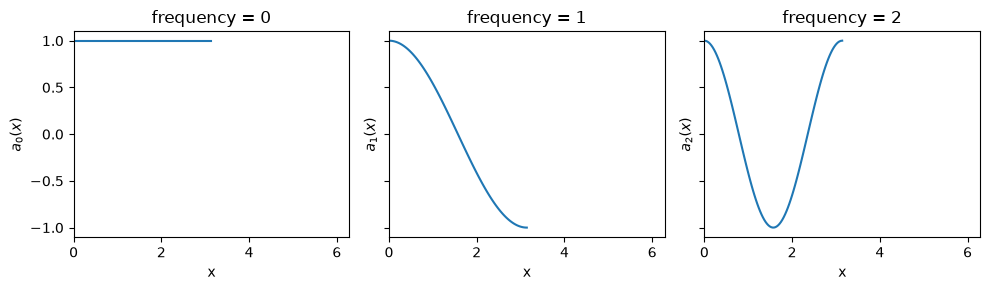

In [9]:
# fix bounds for the range of the input
fourier_1d.bounds = (0, 2*np.pi)

# generate an input not covering the whole range
x = np.linspace(0, np.pi, 100)

# evaluate the basis
X = fourier_1d.compute_features(x)

f, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True)
for freq in [0, 1, 2]:
    axs[freq].set_title(f"frequency = {freq}")
    axs[freq].plot(x, X[:, freq])
    axs[freq].set_xlabel("x")
    axs[freq].set_ylabel(f"$a_{{{freq}}}(x)$")
    axs[freq].set_xlim(0, 2 * np.pi)
plt.tight_layout()
plt.show()

With `bounds=(0, 2π)` fixed but $\boldsymbol{x} \in [0, \pi]$, each frequency $n$ is defined to complete $n$ cycles over the full domain $[0,2\pi]$. Since we are only sampling **half** the domain, each curve shows only the **first half** of those $n$ cycles (e.g., for $n=2$ you see one full cycle).

The bounds can be provided at initialization as well.

In [10]:
fourier_1d = FourierEval(5, bounds=(0, 2*np.pi))
fourier_1d

,frequencies,"[Array([0., 1....dtype=float32)]"
,bounds,"(0.0, ...)"
,ndim,1
,frequency_mask,'no-intercept'
,label,'FourierEval'


:::{dropdown} More on the Bounds
:color: info
:icon: info


When bounds $b_{\min} < b_{\max}$, are provided, the mapping from input $\boldsymbol{x}=(x_1,\ldots,x_T)$ to the $n\text{-th}$ basis element works as follows.,

$$
a_n(x_j)
=
\begin{cases}
\cos\!\left(2\pi n\,\frac{x_j-b_{\min}}{b_{\max}-b_{\min}}\right)
\;+\; i\,\sin\!\left(2\pi n\,\frac{x_j-b_{\min}}{b_{\max}-b_{\min}}\right) && \text{if } x_j \in [b_{\min}, b_{\max}] \\
\text{NaN} && \text{otherwise}
\end{cases}
$$

for $j=1,\ldots,T$.

In other words,

* The fundamental period over $x$ is $P=b_{\max} - b_{\min}$: the $n$-th basis element completes $n$ full cycles as $x$ runs from $b_{\min}$ to $b_{\max}$.
* The phase is zero at $b_{\min}$: $\;a_n(b_{\min})=1+0i$.
* The basis evaluated at samples lying outside the bounds will return a NaN.

:::

## Multi-Dimensional Fourier Basis

Fourier bases extend to $D$ dimensions. Let $\mathbf{x}=(x_1,\dots,x_D)$, per-axis periods $\mathbf{P}=(P_1,\dots,P_D)$, and multi-index $\mathbf{n}=(n_1,\dots,n_D)$ (the set of multi-indices actually retained is described in [Avoiding redundant frequencies](redundant-fourier-freqs) below).

A $D$-dimensional **basis element** is

$$
a_{\mathbf{n}}(\mathbf{x}) \;=\; \cos\!\left( 2\pi \sum_{d=1}^{D} \frac{n_d}{P_d}\, x_d \right)
\;+\; i\,\sin\!\left( 2\pi \sum_{d=1}^{D} \frac{n_d}{P_d}\, x_d \right).
$$

:::{note}

For simplicity, in the rest of the session we will focus on a 2D example, but everything holds true for a general D-dimensional basis.
:::

(redundant-fourier-freqs)=
### Avoiding redundant frequencies

In one dimension only non-negative frequencies are needed: $a_{-n}$ adds nothing to $a_n$, since the cosine is even and the sine is odd. The same redundancy holds for the multi-index when $D \ge 2$ — $\mathbf{n}$ and $-\mathbf{n}$ give the same cosine and a sign-flipped sine, so their feature pairs are linearly dependent. NeMoS therefore keeps one representative of each $\{\mathbf{n},-\mathbf{n}\}$ pair: the all-zero index (DC), or the index whose **first non-zero coordinate is positive**.

You still pass **non-negative** frequencies per axis; NeMoS mirrors the trailing axes to add their negative frequencies and keeps that half-space. In practice:

- the **leading axis stays non-negative**;
- on the trailing axes both signs are kept whenever a preceding coordinate is already positive — e.g. $(1, m)$ is kept for $m$ of either sign, because $(1, m)$ and $(1, -m)$ are genuinely different functions;
- but an index that is zero up to some axis $i$ is kept only if its first non-zero entry is positive — e.g. of $(0, m)$ and $(0, -m)$ only the one with $m>0$ is kept.

### Definition in NeMoS

First, let's specify the notation to the 2D case used in the examples. We can write $\mathbf{x}=(x,y)$, and $\mathbf{n}=(n,m)$; we’ll use $n$ for the $x$-axis frequency and $m$ for the $y$-axis frequency.

Defining a two-dimensional Fourier basis follows the syntax:

In [11]:
# 2D basis with n=0,...,4 (x-axis) and m=0,...,3 (y-axis) frequencies
fourier_2d = FourierEval(frequencies=[5, 4], ndim=2)

# Equvalent definitons
print("Pass a list of tuple:\n", FourierEval(frequencies=[(0, 5), (0, 4)], ndim=2))
print("Pass a list of arrays:\n", FourierEval(frequencies=[np.arange(5), np.arange(4)], ndim=2))


Pass a list of tuple:
 FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32), Array([0., 1., 2., 3.], dtype=float32)], ndim=2, frequency_mask='no-intercept')


Pass a list of arrays:
 FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32), Array([0., 1., 2., 3.], dtype=float32)], ndim=2, frequency_mask='no-intercept')


The $y$-axis is mirrored internally to $7$ signed frequencies, so the half-space of this $5\times 4$ grid has $32$ pairs (including the DC). The DC pair $\mathbf{n}=(0,0)$ is dropped by default, leaving $31$ pairs, each contributing a cosine and a sine: $2\cdot 31 = 62$ features.

In [12]:
fourier_2d.n_basis_funcs

62

All the frequency pairs are stored in the `masked_frequencies` array of shape `(ndim, n_frequency_pairs)`.

:::{note}

`masked_frequencies` lists the frequency pairs that are currently active in the basis. If you later mask out some pairs, this array will update to include only the kept ones. Details follow in the [frequency selection section](select-fourier-freqs-ndim).
:::

In [13]:
print("frequency pairs:\n", fourier_2d.masked_frequencies)
print("shape of the `masked_frequencies` array:", fourier_2d.masked_frequencies.shape)

frequency pairs:
 [[ 0.  0.  0.  1.  1.  1.  1.  1.  1.  1.  2.  2.  2.  2.  2.  2.  2.  3.
   3.  3.  3.  3.  3.  3.  4.  4.  4.  4.  4.  4.  4.]
 [ 1.  2.  3. -3. -2. -1.  0.  1.  2.  3. -3. -2. -1.  0.  1.  2.  3. -3.
  -2. -1.  0.  1.  2.  3. -3. -2. -1.  0.  1.  2.  3.]]
shape of the `masked_frequencies` array: (2, 31)


:::{note}

You can check for the presence of the DC term by assessing if `fourier_2d.masked_frequencies[:, 0]` is all zeros.
:::

(select-fourier-freqs-ndim)=
### Selecting The Frequencies

The `frequencies` argument specifies, **per axis**, which **non-negative** integer frequencies to use. NeMoS mirrors the trailing axes to add negative frequencies and keeps the half-space (see [Avoiding redundant frequencies](redundant-fourier-freqs)); the retained multi-indices $\mathbf{n}$ are listed in `masked_frequencies`.

In [14]:
fourier_2d = FourierEval(frequencies=[np.array([1,2,3]), np.array([4,5])], ndim=2)

print(fourier_2d.masked_frequencies)

[[ 1.  1.  1.  1.  2.  2.  2.  2.  3.  3.  3.  3.]
 [-5. -4.  4.  5. -5. -4.  4.  5. -5. -4.  4.  5.]]


Here you pass $n \in \{1,2,3\}$ and $m \in \{4,5\}$. The $y$-axis is mirrored to $m \in \{-5,-4,4,5\}$. Because every $n \ge 1$ is already positive, the leading coordinate fixes the half-space and **all** sign combinations of $m$ are kept — $3 \times 4 = 12$ pairs $(n,m)$, including the negative $y$-frequencies printed above.

You can subselect specific pairs by **masking**. The mask can be:

1. A 1-D boolean array with one entry per retained pair, i.e. per column of `masked_frequencies`.
2. A function `f(n, m) -> True/False`.

#### Mask With a Boolean Array

Entry $i$ of the mask keeps (`True`/1) or drops (`False`/0) the pair `masked_frequencies[:, i]`. The workflow is to inspect `masked_frequencies` and build the mask from its columns, by hand or with vectorized comparisons. For example, let's keep the pairs $(1,4), (2,4), (2,5)$:

In [15]:
pairs = fourier_2d.masked_frequencies
frequency_mask = ((pairs[0] == 1) & (pairs[1] == 4)) | ((pairs[0] == 2) & (pairs[1] > 0))
print("frequency mask")
print(frequency_mask.astype(int))

fourier_2d.frequency_mask = frequency_mask
print("\nmasked frequencies")
print(fourier_2d.masked_frequencies)

frequency mask


[0 0 1 0 0 0 1 1 0 0 0 0]



masked frequencies
[[1. 2. 2.]
 [4. 4. 5.]]


An array mask always filters the **current** `masked_frequencies`: assigning a second array mask filters the already-filtered pairs, and it must have one entry per remaining pair. To start over from the full half-space, reset the mask to `"all"` (or `"no-intercept"`):

In [16]:
fourier_2d.frequency_mask = "all"
print(fourier_2d.masked_frequencies)

[[ 1.  1.  1.  1.  2.  2.  2.  2.  3.  3.  3.  3.]
 [-5. -4.  4.  5. -5. -4.  4.  5. -5. -4.  4.  5.]]


The mask can address the DC pair whenever it is among the current pairs: for example, construct with `frequency_mask="all"` and frequencies that include 0 (as an integer specification like `frequencies=5` does), then assign the array mask.

A mask whose length does not match the number of retained pairs raises an error pointing you back to `masked_frequencies`:

In [17]:
fourier_2d.frequency_mask = np.ones(5)

ValueError: Mis-shaped ``frequency_mask``. An array mask must have shape ``(12,)``, one entry per frequency combination: entry ``i`` keeps (1/True) or drops (0/False) the combination ``masked_frequencies[:, i]``. Print the ``masked_frequencies`` attribute to see the combinations currently included.

#### Mask With a Callable

Alternatively, we can specify complex masking rules by defining a mask function. For example, let's filter for the frequency pairs that lies inside a circle of radius of 4.5.

In [18]:
frequency_mask = lambda x, y: np.sqrt(x**2 + y**2) < 4.5
fourier_2d.frequency_mask = frequency_mask

print("\nmasked frequencies")
print(fourier_2d.masked_frequencies)


masked frequencies
[[ 1.  1.  2.  2.]
 [-4.  4. -4.  4.]]


:::{admonition} More on Masking with Callables

- Write the function as `f(n, m)` for 2D. The first argument maps to `masked_frequencies[0]` (x-axis, $n$), the second to `masked_frequencies[1]` (y-axis, $m$). In $D$ dimensions use `f(n1, ..., nD)` in the same row order as `masked_frequencies`.
- NeMoS evaluates the function once per half-space combination, passing the frequencies as **scalars** (the signed $\mathbf{n}$, so $m$ may be negative). It must return a single boolean or 0/1 — `True` keeps that $(n,m)$, `False` drops it.
- Unlike an array mask, a callable is always applied to the **full** half-space (including the DC pair), regardless of the mask currently in place.
:::

### Setting the Periodicities

By default, each axis uses its own input span as the period, reusing the 1D rule per axis:
$P_d=\max(\boldsymbol{x}_d)-\min(\boldsymbol{x}_d)$.

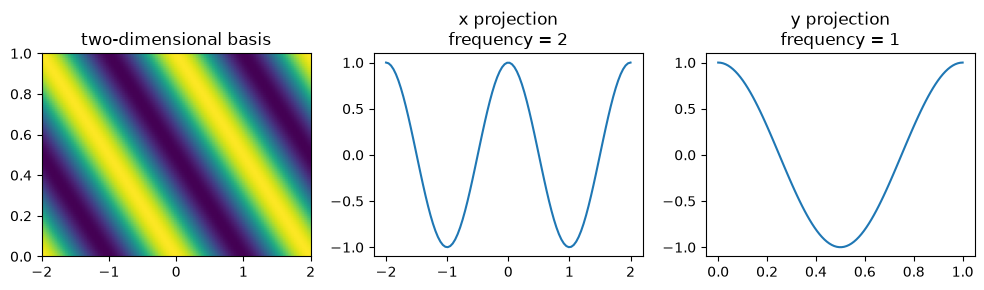

In [19]:
fourier_2d = FourierEval(frequencies=[5, 4], ndim=2)

x, y = np.meshgrid(
    np.linspace(-2, 2,100),
    np.linspace(0, 1, 100),
)
X = fourier_2d.compute_features(x.flatten(), y.flatten())
# reshape to match the (100, 100) grid
X = X.reshape(100, 100, fourier_2d.n_basis_funcs)

# select frequencies n=2, m=1
idx = np.where(
    (fourier_2d.masked_frequencies[0] == 2) &
    (fourier_2d.masked_frequencies[1] == 1)
)[0][0]

# plot the output
f, axs = plt.subplots(1, 3, figsize=(10, 3))

# 2-dimensional basis
axs[0].pcolormesh(x, y, X[..., idx], shading='gouraud', cmap='viridis')
axs[0].set_title("two-dimensional basis")

# 1-dimensional projections
axs[1].plot(x[0], X[0, :, idx])
axs[1].set_title("x projection\nfrequency = 2")

axs[2].plot(y[:, 0], X[:, 0, idx])
axs[2].set_title("y projection\nfrequency = 1")
plt.tight_layout()
plt.show()

As we can see, the $x$-projection, the basis element with $n=2$ completes two cycles across the sampled $x$ range, and on the $y$ projection, the basis element with $m=1$ completes one cycle.

One can set the period by providing a single ``bounds`` tuple that applies to all dimensions, or one tuple per dimension.

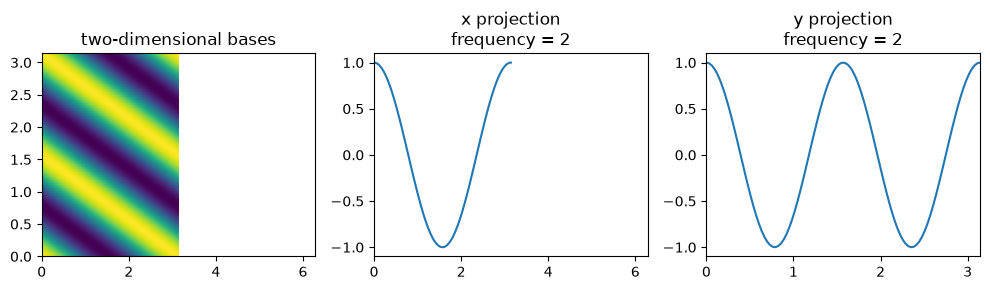

In [20]:
# assign a different domain per dimension
fourier_2d.bounds = [(0, 2*np.pi), (0, np.pi)]

x, y = np.meshgrid(
    np.linspace(0, np.pi,100),  # x spans the half of the domain
    np.linspace(0, np.pi, 100), # y spans the whole domain
)

X = fourier_2d.compute_features(x.flatten(), y.flatten())
# reshape to match the (100, 100) grid
X = X.reshape(100, 100, fourier_2d.n_basis_funcs)

# select frequencies n=2, m=2
idx = np.where(
    (fourier_2d.masked_frequencies[0] == 2) &
    (fourier_2d.masked_frequencies[1] == 2)
)[0][0]

# plot the values
f, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].pcolormesh(x, y, X[..., idx], shading='gouraud', cmap='viridis')
axs[0].set(xlim=(0, 2*np.pi), ylim=(0, np.pi))
axs[0].set_title("two-dimensional bases")

axs[1].plot(x[0], X[0, :, idx])
axs[1].set_title("x projection\nfrequency = 2")
# x domain [0, 2 pi]
axs[1].set_xlim(0, 2*np.pi)

axs[2].plot(y[:, 0], X[:, 0, idx])
axs[2].set_title("y projection\nfrequency = 2")
# y domain [0, pi]
axs[2].set_xlim(0, np.pi)
plt.tight_layout()
plt.show()

With bounds $[(0, 2\pi), (0, \pi)]$ and samples on $x \in [0, \pi]$, the $x$-projection for $n=2$ shows only the first half of its defined period (one full cycle over $[0,\pi]$). The $y$-projection covers its full domain $[0,\pi]$, so for $m=2$ it shows two cycles.


## Composing with the Fourier basis

Like other bases, the Fourier basis composes with NeMoS bases—with one important caveat.

* **Addition**

  Unrestricted: you can add a Fourier basis to any other basis (including another Fourier).

In [21]:
from nemos.basis import BSplineEval

fourier = FourierEval(5)
bspline = BSplineEval(5)

# adding two fourier is valid
print(fourier + fourier)

# adding a fourier and any other basis works too
print(fourier + bspline)

'(FourierEval + FourierEval_1)': AdditiveBasis(
    basis1=FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32)], ndim=1, frequency_mask='no-intercept'),
    basis2='FourierEval_1': FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32)], ndim=1, frequency_mask='no-intercept'),
)
'(FourierEval + BSplineEval)': AdditiveBasis(
    basis1=FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32)], ndim=1, frequency_mask='no-intercept'),
    basis2=BSplineEval(n_basis_funcs=5, order=4),
)


* **Multiplication:**

  A Fourier basis stores **one frequency** as **two columns**: a cosine column and a sine column. Those two together act like **one feature**.

  When you multiply two bases, NeMoS multiplies **every column with every other column**. If both sides are Fourier bases, that means you mix **cos parts with sin parts from different frequencies**. You don’t end up with “one new frequency” — you get **several unrelated columns**, and the cosine/sine pairing is **broken**. The result looks valid but **isn’t the Fourier feature you intended**, so we block it to avoid silent mistakes.

  **Rule:** a product can contain **at most one** Fourier basis.

  **What can be done:**
    * Need multi-dimensional Fourier features? Use **one** `FourierEval` with `ndim > 1`.
    * Want to modulate Fourier by something else (splines, raised cosines, etc.)? Multiply **one** Fourier basis by any **real** basis.

In [22]:
from nemos.basis import BSplineEval, FourierEval

fourier = FourierEval(5)
bspline = BSplineEval(5)

# multiplying a fourier basis with a real basis works
mul = fourier * bspline
print(mul)

# multiplying two objects that both contain a Fourier basis raises:
#   - fourier * fourier
#   - fourier * mul
#   - mul * mul
#   - (fourier + bspline) * fourier
mul * mul  # raises by design

'(FourierEval * BSplineEval)': MultiplicativeBasis(
    basis1=FourierEval(frequencies=[Array([0., 1., 2., 3., 4.], dtype=float32)], ndim=1, frequency_mask='no-intercept'),
    basis2=BSplineEval(n_basis_funcs=5, order=4),
)


ValueError: Invalid multiplication between two complex bases.
Fourier basis are complex bases, and the multiplication of a real basis with a Fourier bases results in a complex basis as well. Multiplication between two complex bases is not allowed in NeMoS as it would treat real and imaginary columns alike.